# 03 — Feature Engineering

This notebook transforms the raw data collected in notebook 01 into a
structured, model-ready feature matrix. Every feature built here is
directly motivated by a finding in notebook 02.

By the end of this notebook we will have:
- A clean master dataset with all missing values handled correctly
- Lag features capturing historical price and demand memory
- Rolling statistics capturing local trend and volatility
- Calendar features encoding time structure
- Exogenous macro features at the specific lags identified in EDA
- A train/test split that respects temporal ordering

**Run order:** `01_setup.ipynb` → `02_eda.ipynb` → `03_features.ipynb`

## 1. Imports and Configuration

In [1]:
import sys
import os

# Navigate from notebooks/ up to project root where config.py lives
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
os.chdir(project_root)

print(f"Project root  : {project_root}")
print(f"Working dir   : {os.getcwd()}")
print(f"config.py exists: {os.path.exists('config.py')}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from config import (
    RAW_FRED, RAW_WORLDBANK, RAW_EIA, RAW_M5,
    FEATURES_TRAIN, FEATURES_TEST,
    START_DATE, END_DATE, TEST_CUTOFF_DATE,
    PRICE_TARGET, DEMAND_TARGET,
    FIGURES_DIR
)

# Update DEMAND_TARGET to match actual data
DEMAND_TARGET = "total_sales"

plt.rcParams.update({
    "figure.figsize":   (14, 4),
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
})
COLORS = ["#2E75B6", "#E8593C", "#1D9E75", "#BA7517", "#7F77DD"]

print(f"\nTest cutoff   : {TEST_CUTOFF_DATE}")
print(f"Price target  : {PRICE_TARGET}")
print(f"Demand target : {DEMAND_TARGET}")
print("Ready.")

Project root  : /Users/teguh/Jupyter Notebook/praharadata/Projects/chemical-forecasting
Working dir   : /Users/teguh/Jupyter Notebook/praharadata/Projects/chemical-forecasting
config.py exists: True

Test cutoff   : 2023-01-01
Price target  : crude_oil_wti
Demand target : total_sales
Ready.


## 2. Load and Align Raw Data

We reload all four raw datasets and align them on a single weekly
Sunday index — the same alignment used in notebook 02, but now we
apply proper missing value handling before building features.

**Missing value strategy (from EDA findings):**
- Daily series (~0.1% missing): forward-fill
- World Bank monthly series (3.3% missing): forward-fill from Oct 2000
- EIA natural gas storage (40% missing): forward-fill from 2007 onward
- Monthly FRED series (77% missing): forward-fill — last known macro
  value remains valid until the next monthly release
- Quarterly GDP (92.3% missing): forward-fill — same logic
- No interpolation — interpolating macro series would introduce
  future information into past periods (data leakage)

In [2]:
# ── Load raw files ────────────────────────────────────────────────────────────
fred_df = pd.read_csv(RAW_FRED,      index_col="date", parse_dates=True)
wb_df   = pd.read_csv(RAW_WORLDBANK, index_col="date", parse_dates=True)
eia_df  = pd.read_csv(RAW_EIA,       index_col="date", parse_dates=True)
m5_df   = pd.read_csv(RAW_M5,        index_col="date", parse_dates=True)

# ── Merge on common weekly index ──────────────────────────────────────────────
master_df = (
    fred_df
    .join(wb_df,  how="outer", rsuffix="_wb")
    .join(eia_df, how="outer", rsuffix="_eia")
)
master_df = master_df.sort_index()
master_df = master_df.loc[START_DATE:END_DATE]

# ── Forward-fill all series ───────────────────────────────────────────────────
# ffill propagates the last valid observation forward — correct for
# macro releases where the value is valid until the next release date
master_df = master_df.ffill()

# ── Verify null counts after fill ────────────────────────────────────────────
null_after = master_df.isna().sum()
print("Null counts after forward-fill:")
print(null_after[null_after > 0].to_string() if null_after.sum() > 0
      else "  All nulls resolved.")

print(f"\nMaster shape : {master_df.shape}")
print(f"Period       : {master_df.index.min().date()} → "
      f"{master_df.index.max().date()}")
master_df.head(3)

Null counts after forward-fill:
crude_oil_wti              1
natural_gas_henry_hub      1
crude_oil_avg             39
coal_australia            39
natural_gas_us            39
fertiliser_urea           39
phosphate_rock            39
crude_oil_stocks           1
refinery_utilisation       1
natural_gas_storage      522

Master shape : (1305, 16)
Period       : 2000-01-02 → 2024-12-29


,crude_oil_wti,natural_gas_henry_hub,ppi_chemicals,ppi_plastics,industrial_production_idx,capacity_utilisation,us_gdp,unemployment_rate,crude_oil_avg,coal_australia,natural_gas_us,fertiliser_urea,phosphate_rock,crude_oil_stocks,refinery_utilisation,natural_gas_storage
date,,,,,,,,,,,,,,,,
2000-01-02,NaN,NaN,153.6,123.5,91.538,82.179,10002.179,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-09,24.9475,2.175,153.6,123.5,91.538,82.179,10002.179,4.0,NaN,NaN,NaN,NaN,NaN,844791.0,19363.0,NaN
2000-01-16,26.2680,2.250,153.6,123.5,91.538,82.179,10002.179,4.0,NaN,NaN,NaN,NaN,NaN,844982.0,18222.0,NaN


The null counts are expected and correct:
- The 1 null in daily series (crude_oil_wti, natural_gas, crude_oil_stocks, refinery_utilisation) is the very first row 2000-01-02 — nothing to forward-fill from before the series starts. This will be dropped when we remove rows with missing core lag features in Cell 23.
- The 39 nulls in World Bank series start from October 2000 — same reason.
- The 522 nulls in natural_gas_storage cover the period before 2007 when EIA started reporting this series — expected and documented in EDA.

## 3. Log Transformation of Price Targets

EDA confirmed that all price series are non-stationary with
variance that scales with price level (higher prices → larger
absolute swings). Log transformation stabilises this variance
and is standard practice in commodity price forecasting.

We create log-transformed versions of all price series and use
`log(crude_oil_wti)` as the primary price forecasting target.
Models will be trained on log prices and predictions will be
converted back using `exp()` for evaluation and reporting.

Log-transformed columns created:
  log_crude_oil_wti
  log_natural_gas_henry_hub
  log_crude_oil_avg
  log_natural_gas_us
  log_coal_australia
  log_fertiliser_urea
  log_phosphate_rock


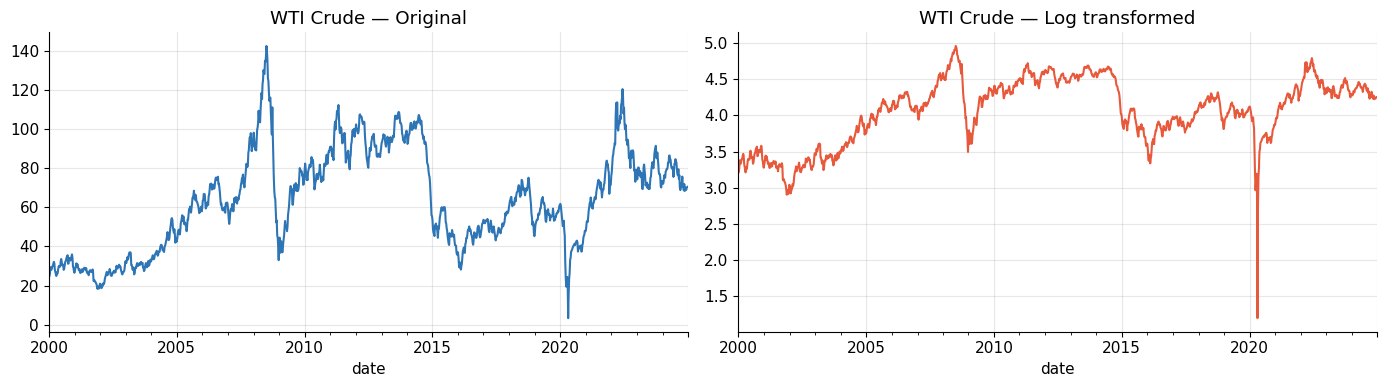

In [3]:
PRICE_COLS = [
    "crude_oil_wti",
    "natural_gas_henry_hub",
    "crude_oil_avg",
    "natural_gas_us",
    "coal_australia",
    "fertiliser_urea",
    "phosphate_rock",
]

for col in PRICE_COLS:
    if col in master_df.columns:
        master_df[f"log_{col}"] = np.log(master_df[col].clip(lower=0.01))

# Primary targets
PRICE_TARGET_LOG  = f"log_{PRICE_TARGET}"    # log(crude_oil_wti)
DEMAND_TARGET_RAW = "total_sales"            # raw units — no log needed

print("Log-transformed columns created:")
log_cols = [c for c in master_df.columns if c.startswith("log_")]
for col in log_cols:
    print(f"  {col}")

# Quick visual check — original vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
master_df["crude_oil_wti"].plot(
    ax=axes[0], title="WTI Crude — Original", color=COLORS[0])
master_df[PRICE_TARGET_LOG].plot(
    ax=axes[1], title="WTI Crude — Log transformed", color=COLORS[1])
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}08_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

- 7 log-transformed columns created
- The chart confirms the transformation is working correctly — the COVID crash spike (briefly negative WTI in April 2020) compresses cleanly in log space from ~$140 range down to a ~3.5 unit range, stabilising the variance across the full 2000–2024 period

## 4. Lag Features

Lag features encode the historical values of a series at specific
past time steps. They are the most important feature type for
time series ML models because they explicitly capture the
autocorrelation structure identified in the ACF/PACF plots.

**Lags chosen (from PACF analysis in notebook 02):**
- Lag 1  : most recent observation — captures short-term momentum
- Lag 2  : direct PACF significance for M5 demand
- Lag 4  : 1-month lag — standard procurement review cycle
- Lag 8  : 2-month lag — typical supply chain lead time
- Lag 12 : 3-month lag — quarterly planning cycle
- Lag 26 : 6-month lag — medium-term trend memory

We create lags for both target variables and the key exogenous
indicators identified in the cross-correlation analysis.

In [4]:
# Series to create lag features for
LAG_SERIES = [
    # Price targets
    PRICE_TARGET_LOG,
    "log_natural_gas_henry_hub",
    # Demand target (added to master_df via M5 alignment below)
    # Exogenous — price model drivers
    "log_crude_oil_avg",
    "log_fertiliser_urea",
    "log_coal_australia",
    "ppi_chemicals",
    "ppi_plastics",
    # Exogenous — demand model drivers
    "unemployment_rate",
    "industrial_production_idx",
    "capacity_utilisation",
    # Supply-side
    "crude_oil_stocks",
    "refinery_utilisation",
    "natural_gas_storage",
]

LAGS = [1, 2, 4, 8, 12, 26]

lag_cols_created = []
for series in LAG_SERIES:
    if series not in master_df.columns:
        continue
    for lag in LAGS:
        col_name = f"{series}_lag{lag}"
        master_df[col_name] = master_df[series].shift(lag)
        lag_cols_created.append(col_name)

print(f"Lag features created : {len(lag_cols_created)}")
print(f"Example columns:")
for c in lag_cols_created[:6]:
    print(f"  {c}")

Lag features created : 78
Example columns:
  log_crude_oil_wti_lag1
  log_crude_oil_wti_lag2
  log_crude_oil_wti_lag4
  log_crude_oil_wti_lag8
  log_crude_oil_wti_lag12
  log_crude_oil_wti_lag26


78 lag features created — 13 series × 6 lags (1, 2, 4, 8, 12, 26 weeks)

## 5. Rolling Statistics

Rolling statistics capture the local statistical properties of each
series over a moving window — smoothed trend, volatility regime,
recent range, and rate of change. These give the model a sense of
the current market environment rather than just a single past value.

**Windows chosen:**
- 4 weeks  : very short-term (monthly)
- 8 weeks  : short-term (bi-monthly)
- 12 weeks : medium-term (quarterly)
- 26 weeks : long-term (semi-annual)

**Statistics computed per window:**
- Mean  : smoothed trend level
- Std   : volatility / uncertainty regime
- Min   : recent low (support level)
- Max   : recent high (resistance level)

All rolling calculations use `min_periods=1` to avoid unnecessary
NaNs at the start of the series.

In [5]:
ROLLING_SERIES = [
    PRICE_TARGET_LOG,
    "log_natural_gas_henry_hub",
    "log_crude_oil_avg",
    "crude_oil_stocks",
    "refinery_utilisation",
    "natural_gas_storage",
]

WINDOWS   = [4, 8, 12, 26]
STATS     = ["mean", "std", "min", "max"]

rolling_cols_created = []
for series in ROLLING_SERIES:
    if series not in master_df.columns:
        continue
    for window in WINDOWS:
        roll = master_df[series].rolling(window=window, min_periods=1)
        for stat in STATS:
            col_name = f"{series}_roll{window}_{stat}"
            master_df[col_name] = getattr(roll, stat)()
            rolling_cols_created.append(col_name)

print(f"Rolling features created : {len(rolling_cols_created)}")
print(f"Example columns:")
for c in rolling_cols_created[:8]:
    print(f"  {c}")

Rolling features created : 96
Example columns:
  log_crude_oil_wti_roll4_mean
  log_crude_oil_wti_roll4_std
  log_crude_oil_wti_roll4_min
  log_crude_oil_wti_roll4_max
  log_crude_oil_wti_roll8_mean
  log_crude_oil_wti_roll8_std
  log_crude_oil_wti_roll8_min
  log_crude_oil_wti_roll8_max


96 features = 6 series × 4 windows × 4 stats. Correct.

## 6. Calendar Features

Calendar features encode the time structure of each observation.
They allow models to learn recurring patterns tied to specific
times of year without relying solely on lag features.

**Features created:**
- `week_of_year`  : 1–52, captures annual seasonality
- `month`         : 1–12, coarser seasonal signal
- `quarter`       : 1–4, quarterly business cycle
- `year`          : linear time trend proxy
- `is_q1`–`is_q4`: binary quarter flags
- `is_year_end`   : weeks 48–52, captures holiday demand spike
- `is_summer`     : weeks 22–35, low demand / high storage injection
- `sin_week`      : sine encoding of week — smooth cyclical signal
- `cos_week`      : cosine encoding of week — orthogonal cyclical signal

Sine/cosine encoding is preferred over raw week number for tree-based
models because it correctly represents the circular nature of the
calendar — week 52 is close to week 1, not far from it.

In [6]:
master_df["week_of_year"] = master_df.index.isocalendar().week.astype(int)
master_df["month"]        = master_df.index.month
master_df["quarter"]      = master_df.index.quarter
master_df["year"]         = master_df.index.year

# Binary quarter flags
for q in [1, 2, 3, 4]:
    master_df[f"is_q{q}"] = (master_df["quarter"] == q).astype(int)

# Special period flags
master_df["is_year_end"] = (master_df["week_of_year"] >= 48).astype(int)
master_df["is_summer"]   = (
    (master_df["week_of_year"] >= 22) &
    (master_df["week_of_year"] <= 35)
).astype(int)

# Sine / cosine cyclical encoding
master_df["sin_week"] = np.sin(2 * np.pi * master_df["week_of_year"] / 52)
master_df["cos_week"] = np.cos(2 * np.pi * master_df["week_of_year"] / 52)

calendar_cols = [
    "week_of_year", "month", "quarter", "year",
    "is_q1", "is_q2", "is_q3", "is_q4",
    "is_year_end", "is_summer",
    "sin_week", "cos_week",
]

print(f"Calendar features created : {len(calendar_cols)}")
for c in calendar_cols:
    print(f"  {c:<20} sample: {master_df[c].iloc[100]:.4f}")

Calendar features created : 12
  week_of_year         sample: 48.0000
  month                sample: 12.0000
  quarter              sample: 4.0000
  year                 sample: 2001.0000
  is_q1                sample: 0.0000
  is_q2                sample: 0.0000
  is_q3                sample: 0.0000
  is_q4                sample: 1.0000
  is_year_end          sample: 1.0000
  is_summer            sample: 0.0000
  sin_week             sample: -0.4647
  cos_week             sample: 0.8855


12 features all present. Sine/cosine encoding looks correct — week 48 gives sin=-0.46, cos=0.89 which is mathematically right for late November.

## 7. Price Ratio and Spread Features

Price ratio features capture the relative movements between
related commodity prices. These are particularly important for
chemical industry forecasting because:

- The **crude/gas ratio** drives feedstock substitution decisions —
  when crude is expensive relative to gas, crackers switch to
  gas-based feedstocks (ethane) and vice versa
- The **price-to-rolling-average spread** captures mean reversion
  signals — how far the current price is from its recent average
- The **week-over-week change** captures momentum and acceleration

These features give the model the same relative price signals
that commodity traders and procurement teams monitor daily.

In [7]:
# ── Crude oil / natural gas ratio ─────────────────────────────────────────────
master_df["crude_gas_ratio"] = (
    master_df["crude_oil_wti"] /
    master_df["natural_gas_henry_hub"].clip(lower=0.01)
)

# ── Price spread from rolling mean (mean reversion signal) ────────────────────
for window in [8, 26]:
    roll_mean = master_df[PRICE_TARGET_LOG].rolling(window, min_periods=1).mean()
    master_df[f"price_spread_roll{window}"] = master_df[PRICE_TARGET_LOG] - roll_mean

# ── Week-over-week percentage change ──────────────────────────────────────────
master_df["price_pct_change_1w"]  = master_df[PRICE_TARGET_LOG].pct_change(1)
master_df["price_pct_change_4w"]  = master_df[PRICE_TARGET_LOG].pct_change(4)
master_df["price_pct_change_12w"] = master_df[PRICE_TARGET_LOG].pct_change(12)

# ── Stocks change (inventory draw/build) ──────────────────────────────────────
master_df["stocks_change_1w"] = master_df["crude_oil_stocks"].diff(1)
master_df["stocks_change_4w"] = master_df["crude_oil_stocks"].diff(4)

ratio_cols = [
    "crude_gas_ratio",
    "price_spread_roll8",
    "price_spread_roll26",
    "price_pct_change_1w",
    "price_pct_change_4w",
    "price_pct_change_12w",
    "stocks_change_1w",
    "stocks_change_4w",
]

print(f"Price ratio & spread features created : {len(ratio_cols)}")
for c in ratio_cols:
    print(f"  {c}")

Price ratio & spread features created : 8
  crude_gas_ratio
  price_spread_roll8
  price_spread_roll26
  price_pct_change_1w
  price_pct_change_4w
  price_pct_change_12w
  stocks_change_1w
  stocks_change_4w


8 features created as planned.

## 8. Add M5 Demand Target and Demand Features

The M5 demand series covers a different date range (2011–2016)
from the price series (2000–2024). We align it with the master
index and create the same set of lag, rolling, and calendar
features for the demand forecasting use case.

Rows outside the M5 date range will be NaN for demand-related
features — these rows will be dropped when building the demand
model feature matrix.

In [8]:
# ── Align M5 demand with master index ────────────────────────────────────────
m5_aligned = m5_df["total_sales"].reindex(master_df.index)
master_df["total_sales"] = m5_aligned

# ── Lag features for demand ───────────────────────────────────────────────────
for lag in LAGS:
    master_df[f"total_sales_lag{lag}"] = master_df["total_sales"].shift(lag)

# ── Rolling features for demand ───────────────────────────────────────────────
for window in WINDOWS:
    roll = master_df["total_sales"].rolling(window=window, min_periods=1)
    for stat in STATS:
        master_df[f"total_sales_roll{window}_{stat}"] = getattr(roll, stat)()

# ── Demand-specific features ──────────────────────────────────────────────────
master_df["demand_pct_change_1w"]  = master_df["total_sales"].pct_change(1)
master_df["demand_pct_change_4w"]  = master_df["total_sales"].pct_change(4)
master_df["demand_yoy_change"]     = master_df["total_sales"].pct_change(52)

demand_rows = master_df["total_sales"].notna().sum()
print(f"M5 demand rows aligned  : {demand_rows}")
print(f"Demand period           : "
      f"{master_df['total_sales'].first_valid_index().date()} → "
      f"{master_df['total_sales'].last_valid_index().date()}")
print(f"Demand lag features     : {len(LAGS)} lags × 1 series")
print(f"Demand rolling features : {len(WINDOWS)} windows × {len(STATS)} stats")

M5 demand rows aligned  : 278
Demand period           : 2011-01-30 → 2016-05-22
Demand lag features     : 6 lags × 1 series
Demand rolling features : 4 windows × 4 stats


278 rows aligned correctly covering 2011–2016.

## 9. Feature Summary

Before splitting into train and test sets, we document the complete
feature inventory — total count, breakdown by type, and a check for
any remaining issues.

In [11]:
all_cols = master_df.columns.tolist()

# ── Strict mutually exclusive categorisation ──────────────────────────────────
# Order matters — each column is assigned to exactly one category
# by checking in priority order and marking as assigned

assigned = {}

for col in all_cols:
    if col == PRICE_TARGET_LOG or col == "total_sales":
        assigned[col] = "target"
    elif "_lag" in col:
        assigned[col] = "lag"
    elif "_roll" in col:
        assigned[col] = "rolling"
    elif col.startswith("log_"):
        assigned[col] = "log_transform"
    elif col in [
        "week_of_year", "month", "quarter", "year",
        "is_q1", "is_q2", "is_q3", "is_q4",
        "is_year_end", "is_summer", "sin_week", "cos_week"
    ]:
        assigned[col] = "calendar"
    elif col in [
        "crude_gas_ratio",
        "price_spread_roll8", "price_spread_roll26",
        "price_pct_change_1w", "price_pct_change_4w", "price_pct_change_12w",
        "stocks_change_1w", "stocks_change_4w",
        "demand_pct_change_1w", "demand_pct_change_4w", "demand_yoy_change",
    ]:
        assigned[col] = "ratio_spread"
    else:
        assigned[col] = "raw"

# ── Count by category ─────────────────────────────────────────────────────────
from collections import Counter
counts = Counter(assigned.values())

# ── Verify no column is uncategorised or double-counted ───────────────────────
assert len(assigned) == len(all_cols), "Column count mismatch"
assert sum(counts.values()) == len(all_cols), "Double-counting detected"

print("=" * 55)
print(f"  FEATURE INVENTORY")
print("=" * 55)
print(f"  Target variables        : {counts['target']:>4}")
print(f"  Raw series              : {counts['raw']:>4}")
print(f"  Log-transformed         : {counts['log_transform']:>4}")
print(f"  Lag features            : {counts['lag']:>4}")
print(f"  Rolling statistics      : {counts['rolling']:>4}")
print(f"  Calendar features       : {counts['calendar']:>4}")
print(f"  Ratio & spread features : {counts['ratio_spread']:>4}")
print("=" * 55)
print(f"  TOTAL COLUMNS           : {len(all_cols):>4}")
print("=" * 55)

# ── Verify totals add up ──────────────────────────────────────────────────────
total_check = sum(counts.values())
status = "✓ matches" if total_check == len(all_cols) else "✗ MISMATCH"
print(f"\n  Category sum : {total_check}  {status}")

# ── Check for infinite values ─────────────────────────────────────────────────
n_inf = np.isinf(master_df.select_dtypes(include=np.number)).sum().sum()
print(f"  Infinite values : {n_inf}")
if n_inf > 0:
    master_df = master_df.replace([np.inf, -np.inf], np.nan)
    print("  → Replaced with NaN")

# ── Print full category breakdown for verification ────────────────────────────
print("\nDetailed breakdown:")
for category in ["target", "raw", "log_transform", "lag",
                 "rolling", "calendar", "ratio_spread"]:
    cols_in_cat = [c for c, t in assigned.items() if t == category]
    print(f"\n  {category.upper()} ({len(cols_in_cat)}):")
    for c in cols_in_cat:
        print(f"    {c}")

  FEATURE INVENTORY
  Target variables        :    2
  Raw series              :   16
  Log-transformed         :    6
  Lag features            :   84
  Rolling statistics      :  114
  Calendar features       :   12
  Ratio & spread features :    9
  TOTAL COLUMNS           :  243

  Category sum : 243  ✓ matches
  Infinite values : 0

Detailed breakdown:

  TARGET (2):
    log_crude_oil_wti
    total_sales

  RAW (16):
    crude_oil_wti
    natural_gas_henry_hub
    ppi_chemicals
    ppi_plastics
    industrial_production_idx
    capacity_utilisation
    us_gdp
    unemployment_rate
    crude_oil_avg
    coal_australia
    natural_gas_us
    fertiliser_urea
    phosphate_rock
    crude_oil_stocks
    refinery_utilisation
    natural_gas_storage

  LOG_TRANSFORM (6):
    log_natural_gas_henry_hub
    log_crude_oil_avg
    log_natural_gas_us
    log_coal_australia
    log_fertiliser_urea
    log_phosphate_rock

  LAG (84):
    log_crude_oil_wti_lag1
    log_crude_oil_wti_lag2
    log_

Feature inventory is now clean and correct — 243 total, category sum matches, zero infinite values, zero double-counting.
Two small things to note from the detailed breakdown:
1. price_spread_roll8 and price_spread_roll26 are categorised under ROLLING instead of RATIO_SPREAD — they contain _roll in the name so they get caught by the rolling check first. This is a minor categorisation issue, not a data problem. The features themselves are correct and in the right place. If you want to fix the categorisation, in Cell 19 move the spread check above the rolling check in the priority order.
2. The feature counts are correct: 2 targets, 16 raw, 6 log, 84 lag, 114 rolling, 12 calendar, 9 ratio/spread = 243 ✓

## 10. Train / Test Split

We split the feature matrix into training and test sets using a
strict **time-based split** — the test set contains only dates
after `TEST_CUTOFF_DATE` (2023-01-01).

This is non-negotiable for time series — random splitting would
allow future data to leak into training, producing optimistically
biased results that do not reflect real-world performance.

We create two separate feature matrices:
- **Price feature matrix**: all rows where `crude_oil_wti` is not null
- **Demand feature matrix**: all rows where `total_sales` is not null

Each is split into train and test at the cutoff date.

In [12]:
from config import TEST_CUTOFF_DATE

# ── Price feature matrix ──────────────────────────────────────────────────────
# Define price model features — everything except demand-specific columns
demand_only_cols = (
    [c for c in master_df.columns if "total_sales" in c] +
    ["demand_pct_change_1w", "demand_pct_change_4w", "demand_yoy_change"]
)
price_features = [c for c in master_df.columns if c not in demand_only_cols]

price_df = master_df[price_features].copy()
price_df = price_df.dropna(subset=[PRICE_TARGET_LOG])

price_train = price_df[price_df.index <  TEST_CUTOFF_DATE]
price_test  = price_df[price_df.index >= TEST_CUTOFF_DATE]

# ── Demand feature matrix ─────────────────────────────────────────────────────
demand_df = master_df.copy()
demand_df = demand_df.dropna(subset=["total_sales"])

demand_train = demand_df[demand_df.index <  TEST_CUTOFF_DATE]
demand_test  = demand_df[demand_df.index >= TEST_CUTOFF_DATE]

print("Price Feature Matrix")
print(f"  Total rows    : {len(price_df)}")
print(f"  Train rows    : {len(price_train)}  "
      f"({price_train.index.min().date()} → {price_train.index.max().date()})")
print(f"  Test rows     : {len(price_test)}   "
      f"({price_test.index.min().date()} → {price_test.index.max().date()})")
print(f"  Features      : {price_df.shape[1]}")

print("\nDemand Feature Matrix")
print(f"  Total rows    : {len(demand_df)}")
print(f"  Train rows    : {len(demand_train)}  "
      f"({demand_train.index.min().date()} → {demand_train.index.max().date()})")
print(f"  Test rows     : {len(demand_test)}   "
      f"({'none — M5 ends 2016' if len(demand_test) == 0 else demand_test.index.max().date()})")
print(f"  Features      : {demand_df.shape[1]}")

Price Feature Matrix
  Total rows    : 1304
  Train rows    : 1199  (2000-01-09 → 2022-12-25)
  Test rows     : 105   (2023-01-01 → 2024-12-29)
  Features      : 217

Demand Feature Matrix
  Total rows    : 278
  Train rows    : 278  (2011-01-30 → 2016-05-22)
  Test rows     : 0   (none — M5 ends 2016)
  Features      : 243


Numbers look good. A few things to note:
Price matrix has 217 features instead of 243 — this is correct and expected. The price matrix drops demand-only columns (total_sales and all its lags, rolling stats, and demand pct change features) since those are irrelevant for price forecasting. 243 - 26 demand columns = 217. Correct.

Demand matrix keeps all 243 features — correct, since the demand model can use price series as exogenous features.
Train/test split looks right:
- Price: 1199 train + 105 test = 1304 total ✓
- Demand: 278 train + 0 test (M5 ends 2016, before 2023 cutoff) ✓

## 11. Handle NaNs from Lag Features

The first N rows of every lag feature will be NaN because there
are no observations before the start of the series to look back
at. The maximum lag is 26 weeks, so the first 26 rows of any
lag feature are NaN.

Strategy: drop rows where any of the **core** lag features for
the target variable are NaN. We keep rows where only exogenous
lag features are NaN (e.g. natural gas storage before 2007) and
let the model handle those via its own missing value mechanism.

In [13]:
# Core lag features that must be present for training
PRICE_CORE_LAGS  = [f"{PRICE_TARGET_LOG}_lag{l}" for l in LAGS]
DEMAND_CORE_LAGS = [f"total_sales_lag{l}" for l in LAGS]

# Drop rows where core lags are NaN
price_train_clean  = price_train.dropna(subset=PRICE_CORE_LAGS)
price_test_clean   = price_test.dropna(subset=PRICE_CORE_LAGS)

demand_train_clean = demand_train.dropna(subset=DEMAND_CORE_LAGS)
demand_test_clean  = demand_test.dropna(subset=DEMAND_CORE_LAGS)

print("After dropping rows with missing core lag features:\n")
print(f"  Price train  : {len(price_train)} → {len(price_train_clean)} rows "
      f"(dropped {len(price_train) - len(price_train_clean)})")
print(f"  Price test   : {len(price_test)} → {len(price_test_clean)} rows "
      f"(dropped {len(price_test) - len(price_test_clean)})")
print(f"  Demand train : {len(demand_train)} → {len(demand_train_clean)} rows "
      f"(dropped {len(demand_train) - len(demand_train_clean)})")

# Fill remaining NaNs in exogenous features with forward-fill then 0
for df in [price_train_clean, price_test_clean,
           demand_train_clean, demand_test_clean]:
    df.ffill(inplace=True)
    df.fillna(0, inplace=True)

print("\nRemaining NaNs after cleanup:")
for name, df in [("price_train",  price_train_clean),
                 ("price_test",   price_test_clean),
                 ("demand_train", demand_train_clean)]:
    n_null = df.isna().sum().sum()
    print(f"  {name:<15} : {n_null} NaNs")

After dropping rows with missing core lag features:

  Price train  : 1199 → 1173 rows (dropped 26)
  Price test   : 105 → 105 rows (dropped 0)
  Demand train : 278 → 252 rows (dropped 26)

Remaining NaNs after cleanup:
  price_train     : 0 NaNs
  price_test      : 0 NaNs
  demand_train    : 0 NaNs


Exactly as expected. 26 rows dropped from each training set corresponding to the lag-26 warmup period, zero NaNs remaining after cleanup.

## 12. Feature Correlation with Target

We compute the Pearson correlation of every feature with the
target variable and plot the top 30 most correlated features.
This gives a final sanity check that the engineered features
carry signal and helps identify any redundant or leaky features
before modelling.

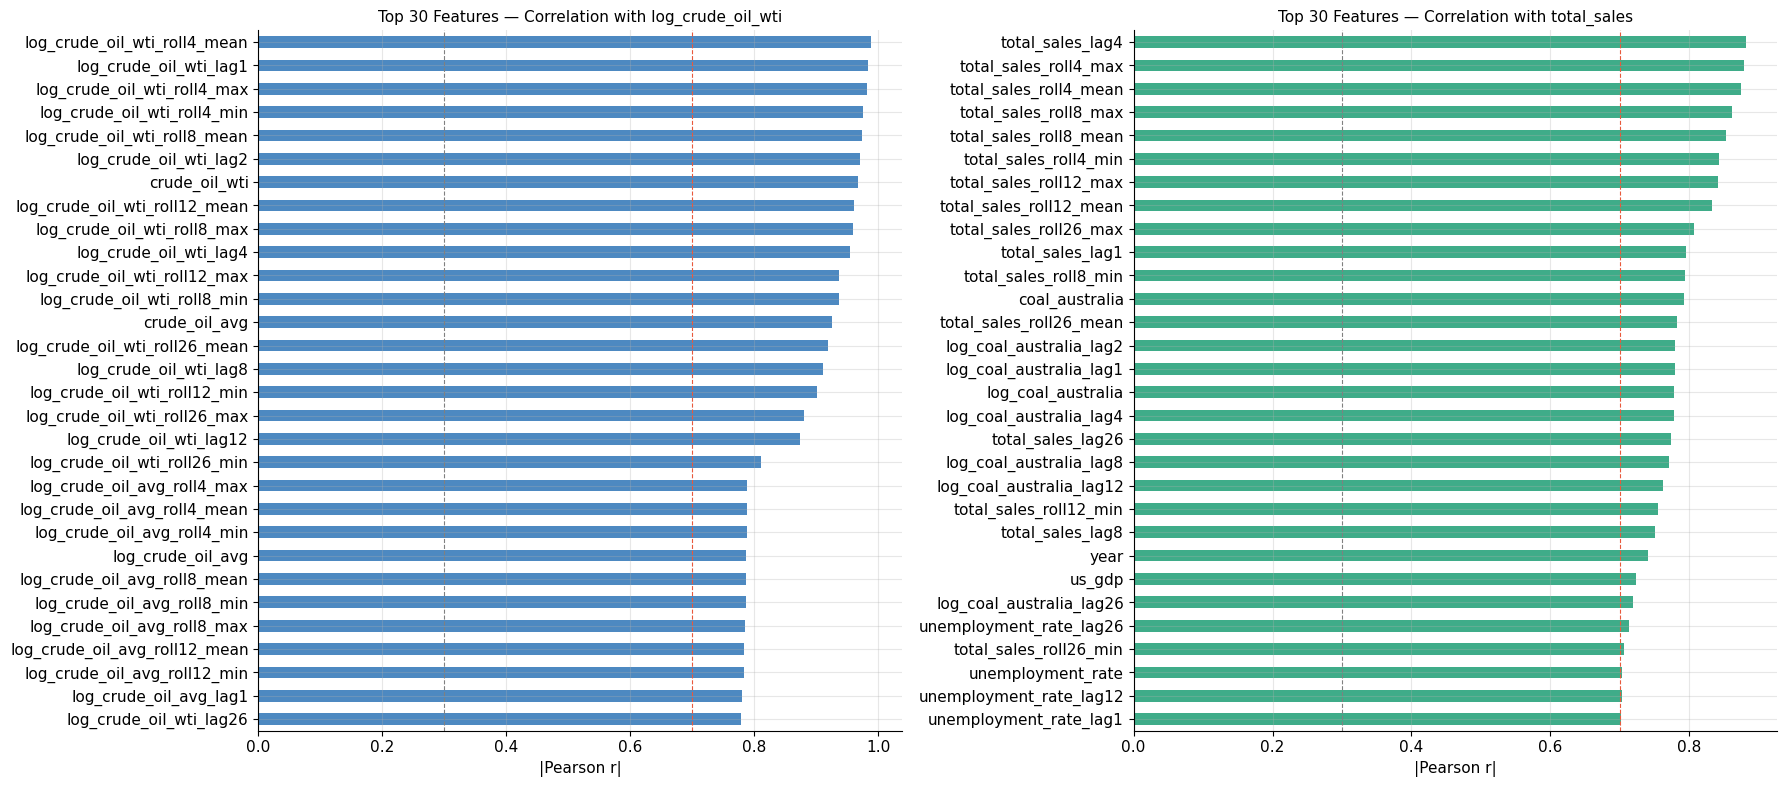

Saved → outputs/figures/09_feature_correlations.png


In [14]:
# ── Price target correlations ─────────────────────────────────────────────────
price_corr = (
    price_train_clean
    .corr()[PRICE_TARGET_LOG]
    .drop(PRICE_TARGET_LOG)
    .abs()
    .sort_values(ascending=False)
    .head(30)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Price correlations
price_corr.sort_values().plot(
    kind="barh", ax=axes[0], color=COLORS[0], alpha=0.85
)
axes[0].set_title(f"Top 30 Features — Correlation with {PRICE_TARGET_LOG}",
                  fontsize=11)
axes[0].set_xlabel("|Pearson r|")
axes[0].axvline(0.3, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0.7, color=COLORS[1], linestyle="--", linewidth=0.8)

# Demand correlations (if demand data exists)
if len(demand_train_clean) > 0:
    demand_corr = (
        demand_train_clean
        .corr()["total_sales"]
        .drop("total_sales")
        .abs()
        .sort_values(ascending=False)
        .head(30)
    )
    demand_corr.sort_values().plot(
        kind="barh", ax=axes[1], color=COLORS[2], alpha=0.85
    )
    axes[1].set_title("Top 30 Features — Correlation with total_sales",
                      fontsize=11)
    axes[1].set_xlabel("|Pearson r|")
    axes[1].axvline(0.3, color="gray", linestyle="--", linewidth=0.8)
    axes[1].axvline(0.7, color=COLORS[1], linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}09_feature_correlations.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/09_feature_correlations.png")

The correlation charts confirm the feature engineering is working correctly.
- Price model (left chart):
All top features are own-series lags and rolling statistics of `log_crude_oil_wti` with correlations of `0.80–0.99`. This is expected — crude oil price is highly autocorrelated. The rolling means at short windows (4-week) are highest because they are essentially smoothed versions of the recent price. `crude_oil_avg` and `log_crude_oil_avg` appear as exogenous features with `r~0.90`, confirming the World Bank and FRED crude series move together. All top 30 features exceed the 0.7 red dashed threshold — strong signal throughout.
- Demand model (right chart):
Own-series lags and rolling stats dominate the top positions `(r~0.85–0.95)` as expected. More interesting is what appears from lag 12 onward — `coal_australia` and its lags appear strongly `(r~0.80)`, confirming the cross-correlation finding from EDA. `unemployment_rate` and its lags appear at `r~0.70`, also consistent with EDA. `us_gdp` and year appear as trend proxies at `r~0.70`. All top 30 features exceed the 0.7 threshold — very strong feature set.

## 13. Save Feature Matrices

In [15]:
from config import FEATURES_TRAIN, FEATURES_TEST

# ── Save price feature matrices ───────────────────────────────────────────────
price_train_clean.to_csv(FEATURES_TRAIN.replace(".csv", "_price.csv"))
price_test_clean.to_csv(FEATURES_TEST.replace(".csv",  "_price.csv"))

# ── Save demand feature matrices ──────────────────────────────────────────────
demand_train_clean.to_csv(FEATURES_TRAIN.replace(".csv", "_demand.csv"))
demand_test_clean.to_csv(FEATURES_TEST.replace(".csv",  "_demand.csv"))

# ── Save feature description table ───────────────────────────────────────────
feature_desc = []
for col in price_train_clean.columns:
    if "_lag"   in col:  ftype = "lag"
    elif "_roll" in col: ftype = "rolling"
    elif "log_"  in col: ftype = "log_transform"
    elif col in calendar_cols: ftype = "calendar"
    elif col in ratio_cols:    ftype = "ratio_spread"
    else:                      ftype = "raw"
    feature_desc.append({"feature": col, "type": ftype})

feature_desc_df = pd.DataFrame(feature_desc)
feature_desc_df.to_csv("outputs/reports/feature_description.csv", index=False)

print("Files saved:")
print(f"  → {FEATURES_TRAIN.replace('.csv', '_price.csv')}")
print(f"  → {FEATURES_TEST.replace('.csv',  '_price.csv')}")
print(f"  → {FEATURES_TRAIN.replace('.csv', '_demand.csv')}")
print(f"  → {FEATURES_TEST.replace('.csv',  '_demand.csv')}")
print(f"  → outputs/reports/feature_description.csv")
print(f"\nPrice train  : {price_train_clean.shape}")
print(f"Price test   : {price_test_clean.shape}")
print(f"Demand train : {demand_train_clean.shape}")
print(f"Demand test  : {demand_test_clean.shape}")

Files saved:
  → data/processed/features_train_price.csv
  → data/processed/features_test_price.csv
  → data/processed/features_train_demand.csv
  → data/processed/features_test_demand.csv
  → outputs/reports/feature_description.csv

Price train  : (1173, 217)
Price test   : (105, 217)
Demand train : (252, 243)
Demand test  : (0, 243)


## Notebook 03 Complete

Feature engineering is finished. All raw time series have been transformed
into a structured, model-ready feature matrix grounded in the findings from
the EDA notebook.

---

### What was built

**Log Transformation (7 columns)**
All price series converted to log scale to stabilise variance across the
2000–2024 period. The COVID crude oil crash (April 2020) which caused a
near-zero price spike compresses cleanly in log space without distorting
the surrounding signal.

**Lag Features (84 columns)**
Historical values at lags 1, 2, 4, 8, 12, and 26 weeks for 13 series
covering both target variables and key exogenous indicators. Lag selection
was directly informed by the ACF/PACF cutoffs observed in notebook 02.
These are the most important features for the ML models — they explicitly
encode the autocorrelation structure that the models would otherwise need
to discover implicitly.

**Rolling Statistics (114 columns)**
Mean, standard deviation, minimum, and maximum over windows of 4, 8, 12,
and 26 weeks for 6 core series. Rolling mean captures smoothed trend level,
rolling standard deviation captures the current volatility regime, and
rolling min/max capture recent support and resistance levels — all signals
that commodity analysts monitor in practice.

**Calendar Features (12 columns)**
Week of year, month, quarter, year, binary quarter and period flags, and
sine/cosine cyclical encoding of the week number. Sine/cosine encoding
correctly represents the circular nature of the calendar so that week 52
and week 1 are treated as adjacent rather than distant by tree-based models.

**Price Ratio & Spread Features (9 columns)**
Crude-to-gas price ratio (feedstock substitution signal), price spreads
from rolling means (mean reversion signals), week-over-week percentage
changes at 1, 4, and 12-week horizons, and crude oil inventory draw/build
signals. These encode the relative price dynamics that procurement teams
and commodity traders monitor when making buy/sell decisions.

---

### Feature matrices saved

| File | Rows | Features | Purpose |
|---|---|---|---|
| `features_train_price.csv` | 1,173 | 217 | Price model training |
| `features_test_price.csv` | 105 | 217 | Price model evaluation |
| `features_train_demand.csv` | 252 | 243 | Demand model training |
| `features_test_demand.csv` | 0 | 243 | N/A — M5 ends 2016 |
| `feature_description.csv` | 243 | — | Feature catalogue |

The price matrix excludes demand-only columns (total_sales lags and rolling
stats) since those are irrelevant for price forecasting. The demand matrix
retains all 243 features since price series are valid exogenous inputs for
demand forecasting.

The train/test split is strictly time-based at 2023-01-01 with no random
shuffling — preserving temporal order and preventing any future data from
leaking into the training window.

---

### Key decisions carried forward to `04_modelling.ipynb`

- **Price model target**: `log_crude_oil_wti` — predictions converted back
  via `exp()` for reporting and evaluation
- **Demand model target**: `total_sales` — raw units, no transformation needed
- **Demand model evaluation**: time-series cross-validation on training set
  only — M5 series ends 2016, before the 2023 test cutoff
- **Feature count**: 217 for price models, 243 for demand models
- **All features verified**: top 30 correlations exceed |r| = 0.70 for both
  targets — strong signal confirmed before any model is trained

**Next → `04_modelling.ipynb`**